## Pruebas con RF

Ejecutando 50 evaluaciones cruzadas para el triaje reducido (RF Top-4)...


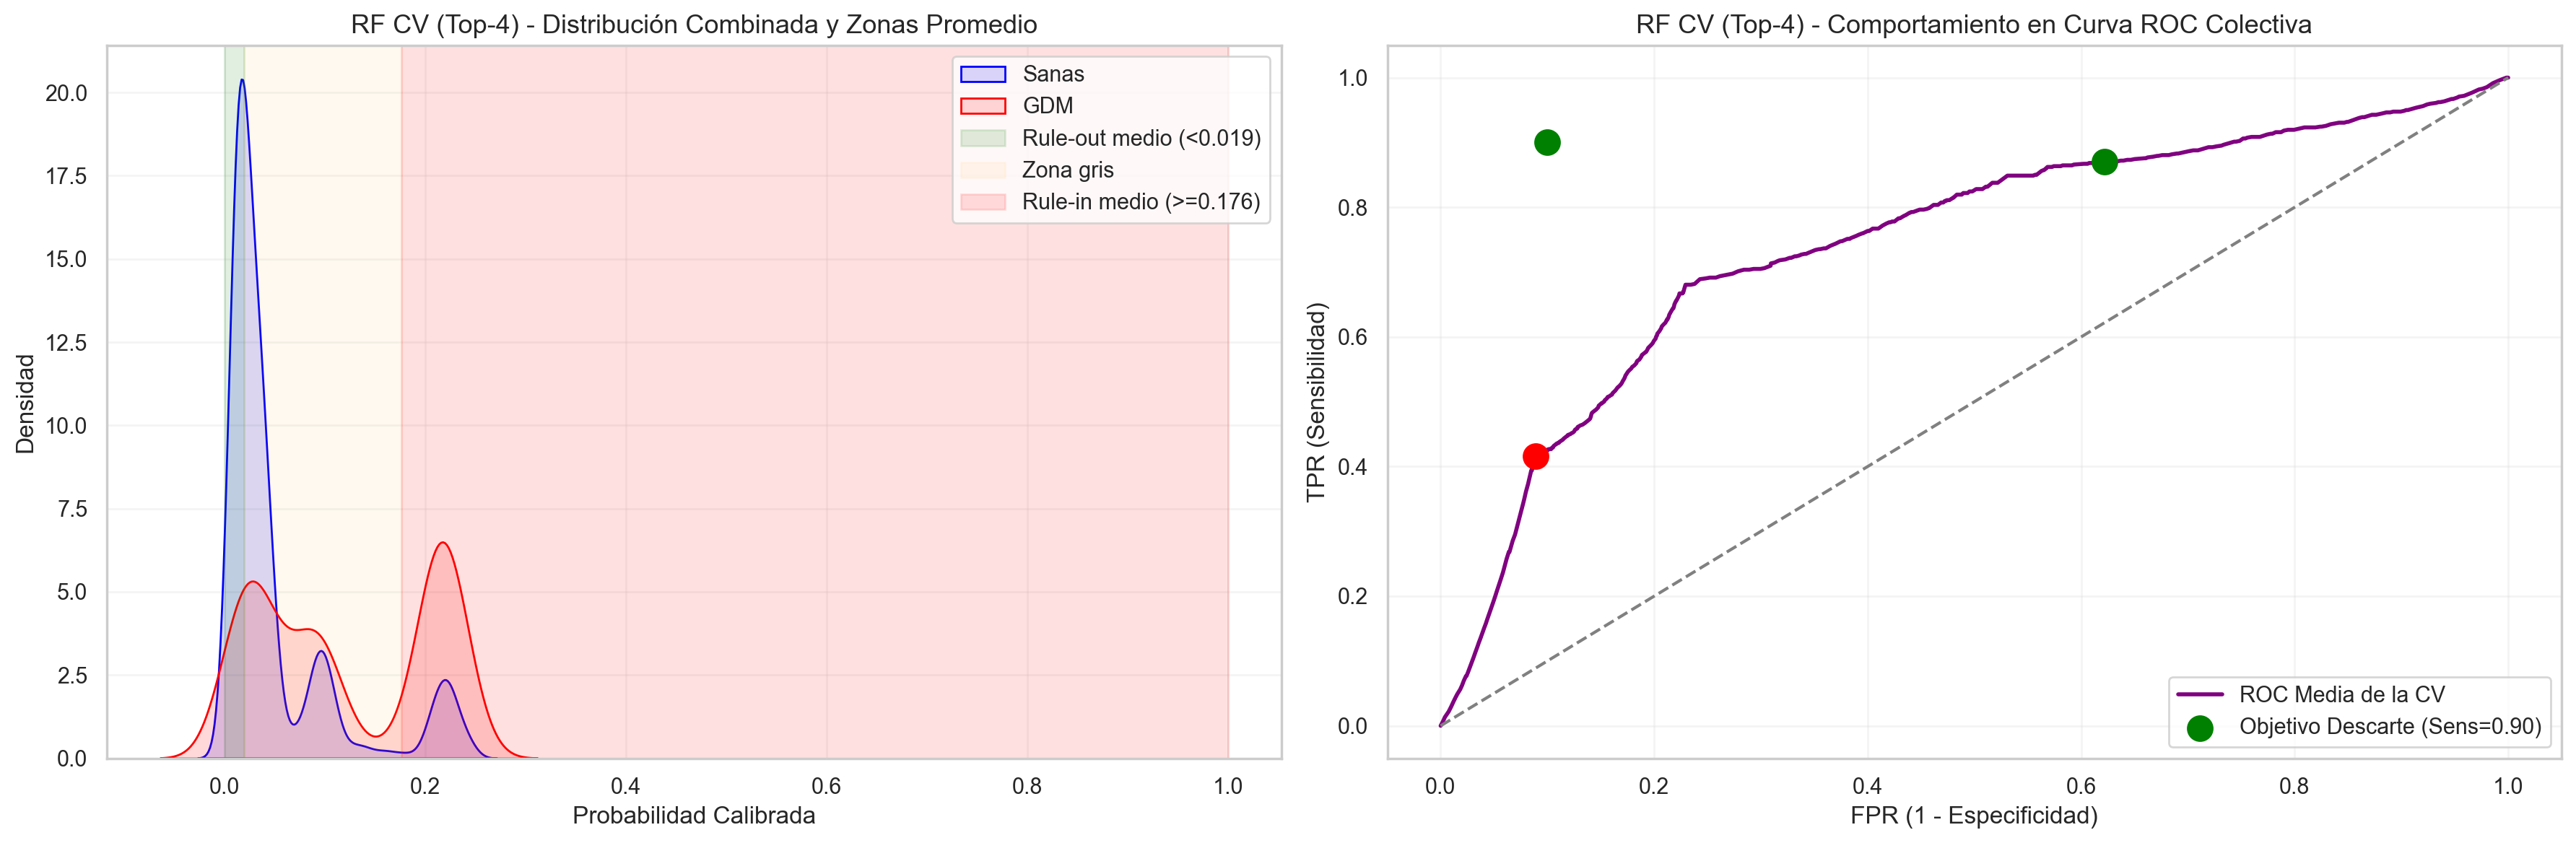


ANÁLISIS DE IMPACTO CLÍNICO REPETIDO (RANDOM FOREST MODELO REDUCIDO TOP-4)
Variables analizadas: ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
AUC-ROC colectiva del espacio reducido: 0.7447
Umbral de Descarte Promedio: 0.0193 ± 0.0113
Umbral de Confirmación Promedio: 0.1762 ± 0.0538
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3380 (22.5%) |   27 pts. |   0.8% | Falla en 27 casos (96.7% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 9805 (65.3%) |  431 pts. |   4.4% | Absorbe al 52.6% de las enfermas
RULE-IN (Confirmación)    | 1835 (12.2%) |  362 pts. |  19.7% | Precisión Real Consolidada del 19.7%
------------------------------------------------------------

In [207]:
# ======================================================================
# 6. Triaje Clínico Robusto mediante Validación Cruzada Repetida (RF TOP-4)
# ======================================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# 1. Comprobaciones de las variables del modelo reducido
if "cuts_seleccionados_rf" not in globals():
    raise NameError("Define primero 'cuts_seleccionados_rf' con tus cortes seleccionados para RF.")
if "top_4_features" not in globals():
    raise NameError("No se encuentra 'top_4_features' en el entorno.")

# Reconstrucción del diccionario de cortes específico para el Top-4
cuts_top4 = {k: cuts_seleccionados_rf.get(k, None) for k in top_4_features}

# 2. Configuración de la validación cruzada para el triaje
n_splits = 5
n_repeats = 10
cv_triaje_rf_top4 = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

modo_thr_in = "precision"
target_sens = 0.90  
target_prec = 0.40  
thr_in_manual = 0.25

# Acumuladores por pliegue para el cálculo del intervalo de confianza (RF Reducido)
ahorros_folds_rf_top4 = []
umbrales_out_rf_top4 = []
umbrales_in_rf_top4 = []
probas_normalizadas_grafico_rf_top4 = []
reales_acumulados_grafico_rf_top4 = []

total_pacientes_evaluados_rf_top4 = 0
total_positivos_evaluados_rf_top4 = 0

counts_globales_rf_top4 = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_rf_top4 = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} evaluaciones cruzadas para el triaje reducido (RF Top-4)...")

# Definición del Pipeline base estructurado exactamente como tu pipe_top4 de comparación
pipe_base_rf_top4 = Pipeline([
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_top4)),
    ("select", FunctionTransformer(lambda X: X[top_4_features], validate=False)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", RandomForestClassifier(
        n_estimators=300, 
        max_depth=5,
        class_weight="balanced", 
        random_state=42, 
        n_jobs=-1
    ))
])

# -----------------------------
# Bucle de validación cruzada repetida
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv_triaje_rf_top4.split(X_train, y_train), start=1):
    X_tr_fold, y_tr_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Calibración isotónica local por pliegue aislado
    calibrador_fold_rf_top4 = CalibratedClassifierCV(estimator=pipe_base_rf_top4, method='isotonic', cv=3)
    calibrador_fold_rf_top4.fit(X_tr_fold, y_tr_fold)
    
    probabilidades_fold_rf_top4 = calibrador_fold_rf_top4.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()
    
    # 1. Optimización local del umbral Rule-Out (Descarte)
    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probabilidades_fold_rf_top4)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else 0.05
    
    # 2. Optimización local del umbral Rule-In (Confirmación)
    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probabilidades_fold_rf_top4)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probabilidades_fold_rf_top4, 90)  # Fallback dinámico si la pérdida de features castiga la precisión
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")
        
    # Corrección de solapamiento físico de seguridad
    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05
        
    umbrales_out_rf_top4.append(thr_out_f)
    umbrales_in_rf_top4.append(thr_in_f)
    
    # Guardar vectores out-of-fold para las curvas colectivas
    probas_normalizadas_grafico_rf_top4.extend(probabilidades_fold_rf_top4.tolist())
    reales_acumulados_grafico_rf_top4.extend(y_val_arr.tolist())
    
    # Clasificación tripartita de las pacientes en este fold
    cats_f = []
    for p in probabilidades_fold_rf_top4:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")
            
    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})
    
    # Contabilidad acumulada
    total_pacientes_evaluados_rf_top4 += len(df_f)
    total_positivos_evaluados_rf_top4 += int(df_f["Real"].sum())
    
    for c in counts_globales_rf_top4.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_rf_top4[c] += len(sub_c)
        positives_globales_rf_top4[c] += int(sub_c["Real"].sum())
        
    # Ahorro neto del pliegue actual para el intervalo de confianza final
    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_rf_top4.append(((len(df_f) - count_gris) / len(df_f)) * 100)

# -----------------------------
# Estadísticos y Curvas Consolidadas
# -----------------------------
mean_thr_out_rf_top4 = float(np.mean(umbrales_out_rf_top4))
mean_thr_in_rf_top4 = float(np.mean(umbrales_in_rf_top4))
std_thr_out_rf_top4 = float(np.std(umbrales_out_rf_top4))
std_thr_in_rf_top4 = float(np.std(umbrales_in_rf_top4))

df_grafico_global_rf_top4 = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_rf_top4,
    "Real": reales_acumulados_grafico_rf_top4
})

auc_cv_global_rf_top4 = roc_auc_score(df_grafico_global_rf_top4["Real"], df_grafico_global_rf_top4["Prob"])

# -----------------------------
# Generación de Gráficas de Control
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_rf_top4[df_grafico_global_rf_top4["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_rf_top4[df_grafico_global_rf_top4["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_rf_top4, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_rf_top4:.3f})")
ax1.axvspan(mean_thr_out_rf_top4, mean_thr_in_rf_top4, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_rf_top4, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={mean_thr_in_rf_top4:.3f})")
ax1.set_title("RF CV (Top-4) - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_rf_top4["Real"], df_grafico_global_rf_top4["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_rf_top4))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_rf_top4))
ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.set_title("RF CV (Top-4) - Comportamiento en Curva ROC Colectiva", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -----------------------------
# Reporte Clínico con Intervalos de Confianza
# -----------------------------
print("\n" + "=" * 90)
print(f"ANÁLISIS DE IMPACTO CLÍNICO REPETIDO (RANDOM FOREST MODELO REDUCIDO TOP-4)")
print("=" * 90)
print(f"Variables analizadas: {top_4_features}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_rf_top4} | Positivos Reales Totales: {int(total_positivos_evaluados_rf_top4)}")
print(f"AUC-ROC colectiva del espacio reducido: {auc_cv_global_rf_top4:.4f}")
print(f"Umbral de Descarte Promedio: {mean_thr_out_rf_top4:.4f} ± {std_thr_out_rf_top4:.4f}")
print(f"Umbral de Confirmación Promedio: {mean_thr_in_rf_top4:.4f} ± {std_thr_in_rf_top4:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_rf_top4[cat]
    positives = positives_globales_rf_top4[cat]
    perc_total = (count / total_pacientes_evaluados_rf_top4) * 100 if total_pacientes_evaluados_rf_top4 > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_rf_top4) * 100 if total_positivos_evaluados_rf_top4 > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_rf_top4) * 100:.1f}% de las enfermas" if total_positivos_evaluados_rf_top4 > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO (RF TOP-4): Se evita la prueba al {np.mean(ahorros_folds_rf_top4):.1f}% ± {np.std(ahorros_folds_rf_top4):.1f}% de la población analizada.")
print("=" * 90)

## Pruebas con SVM

Ejecutando 50 evaluaciones cruzadas para el triaje reducido (SVM Top-4)...


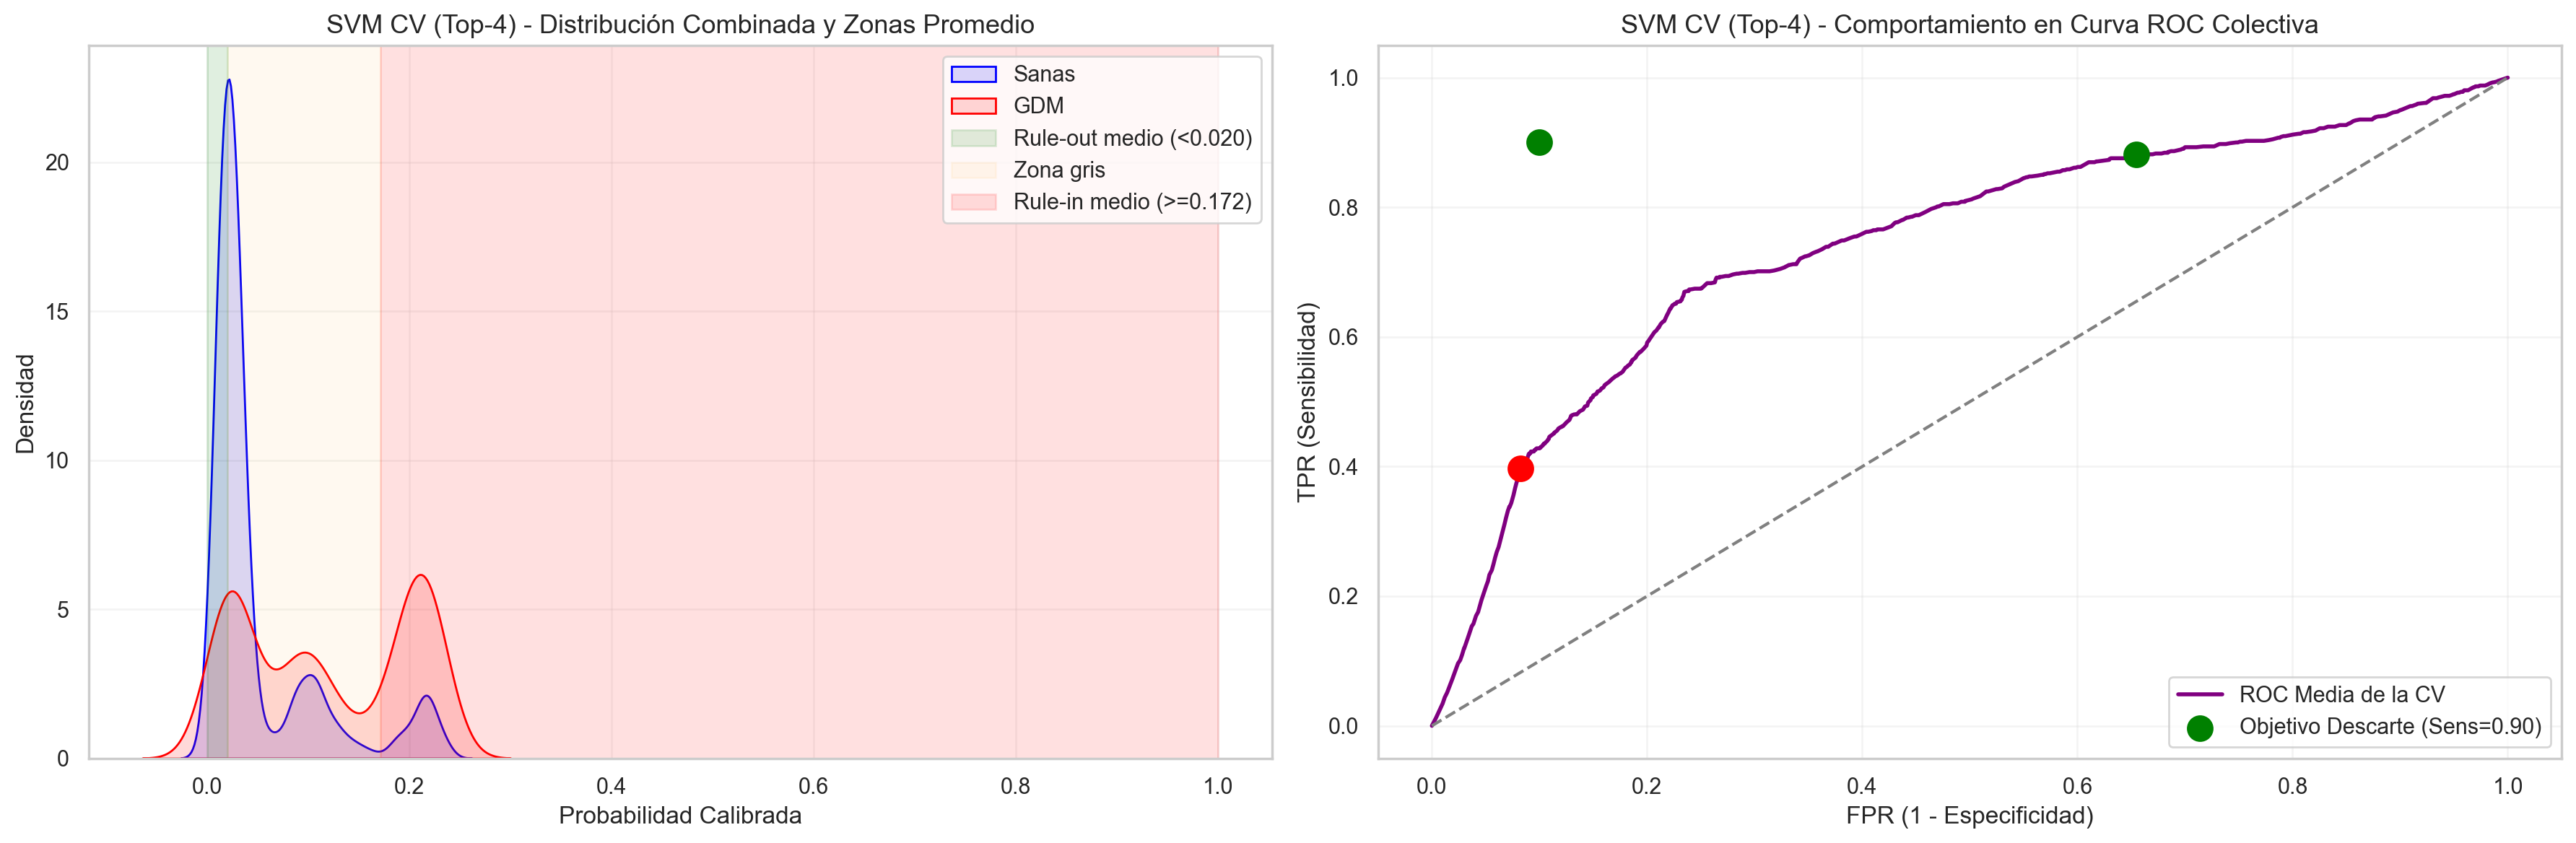


ANÁLISIS DE IMPACTO CLÍNICO REPETIDO (SVM MODELO REDUCIDO TOP-4)
Variables analizadas: ['1t glucosa', '1T hemoglobina glicada', 'bmi', 'edad']
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
AUC-ROC colectiva del espacio reducido: 0.7432
Umbral de Descarte Promedio: 0.0205 ± 0.0084
Umbral de Confirmación Promedio: 0.1718 ± 0.0461
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3229 (21.5%) |   32 pts. |   1.0% | Falla en 32 casos (96.1% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 9949 (66.2%) |  424 pts. |   4.3% | Absorbe al 51.7% de las enfermas
RULE-IN (Confirmación)    | 1842 (12.3%) |  364 pts. |  19.8% | Precisión Real Consolidada del 19.8%
----------------------------------------------------------------------

In [202]:
# ======================================================================
# 6. Triaje Clínico Robusto mediante Validación Cruzada Repetida (SVM TOP-4)
# ======================================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# 1. Comprobaciones de las variables del modelo reducido
if "cuts_seleccionados_rf" not in globals():
    raise NameError("Define primero 'cuts_seleccionados_rf' con tus cortes seleccionados.")
if "top_4_features" not in globals():
    raise NameError("No se encuentra 'top_4_features' en el entorno.")

# Reconstrucción del diccionario de cortes específico para el Top-4
cuts_top4 = {k: cuts_seleccionados_rf.get(k, None) for k in top_4_features}

# 2. Configuración de la validación cruzada para el triaje
n_splits = 5
n_repeats = 10
cv_triaje_svm_top4 = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

modo_thr_in = "precision"
target_sens = 0.90  
target_prec = 0.40  
thr_in_manual = 0.25

# Acumuladores por pliegue para el cálculo del intervalo de confianza (Muestra Reducida)
ahorros_folds_svm_top4 = []
umbrales_out_svm_top4 = []
umbrales_in_svm_top4 = []
probas_normalizadas_grafico_svm_top4 = []
reales_acumulados_grafico_svm_top4 = []

total_pacientes_evaluados_svm_top4 = 0
total_positivos_evaluados_svm_top4 = 0

counts_globales_svm_top4 = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_svm_top4 = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} evaluaciones cruzadas para el triaje reducido (SVM Top-4)...")

# Definición del esqueleto del Pipeline base para el Top-4 (sin entrenar)
pipe_base_svm_top4 = Pipeline([
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_top4)),
    ("select", FunctionTransformer(lambda X: X[top_4_features], validate=False)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", SVC(
        kernel="rbf",
        C=0.5,
        gamma="scale",
        class_weight="balanced",
        probability=True
    ))
])

# -----------------------------
# Bucle de validación cruzada repetida
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv_triaje_svm_top4.split(X_train, y_train), start=1):
    X_tr_fold, y_tr_fold = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_val_fold, y_val_fold = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # Clonamos el pipeline base y aplicamos la calibración isotónica en el bucle local
    calibrador_fold_svm_top4 = CalibratedClassifierCV(estimator=pipe_base_svm_top4, method='isotonic', cv=3)
    calibrador_fold_svm_top4.fit(X_tr_fold, y_tr_fold)
    
    probabilidades_fold_svm_top4 = calibrador_fold_svm_top4.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()
    
    # 1. Optimización local del umbral Rule-Out (Descarte)
    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probabilidades_fold_svm_top4)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else 0.05
    
    # 2. Optimización local del umbral Rule-In (Confirmación)
    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probabilidades_fold_svm_top4)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probabilidades_fold_svm_top4, 90)  # Fallback dinámico si se degrada la precisión
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")
        
    # Corrección de solapamiento físico
    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05
        
    umbrales_out_svm_top4.append(thr_out_f)
    umbrales_in_svm_top4.append(thr_in_f)
    
    # Guardar vectores para la visualización out-of-fold global
    probas_normalizadas_grafico_svm_top4.extend(probabilidades_fold_svm_top4.tolist())
    reales_acumulados_grafico_svm_top4.extend(y_val_arr.tolist())
    
    # Clasificación tripartita de las pacientes en este pliegue
    cats_f = []
    for p in probabilidades_fold_svm_top4:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")
            
    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})
    
    # Contabilidad acumulada
    total_pacientes_evaluados_svm_top4 += len(df_f)
    total_positivos_evaluados_svm_top4 += int(df_f["Real"].sum())
    
    for c in counts_globales_svm_top4.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_svm_top4[c] += len(sub_c)
        positives_globales_svm_top4[c] += int(sub_c["Real"].sum())
        
    # Cálculo del ahorro operativo neto del pliegue actual
    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_svm_top4.append(((len(df_f) - count_gris) / len(df_f)) * 100)

# -----------------------------
# Estadísticos y Curvas Consolidadas
# -----------------------------
mean_thr_out_svm_top4 = float(np.mean(umbrales_out_svm_top4))
mean_thr_in_svm_top4 = float(np.mean(umbrales_in_svm_top4))
std_thr_out_svm_top4 = float(np.std(umbrales_out_svm_top4))
std_thr_in_svm_top4 = float(np.std(umbrales_in_svm_top4))

df_grafico_global_svm_top4 = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_svm_top4,
    "Real": reales_acumulados_grafico_svm_top4
})

auc_cv_global_svm_top4 = roc_auc_score(df_grafico_global_svm_top4["Real"], df_grafico_global_svm_top4["Prob"])

# -----------------------------
# Generación de Gráficas de Control
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_svm_top4[df_grafico_global_svm_top4["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_svm_top4[df_grafico_global_svm_top4["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_svm_top4, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_svm_top4:.3f})")
ax1.axvspan(mean_thr_out_svm_top4, mean_thr_in_svm_top4, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_svm_top4, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={mean_thr_in_svm_top4:.3f})")
ax1.set_title("SVM CV (Top-4) - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_svm_top4["Real"], df_grafico_global_svm_top4["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_svm_top4))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_svm_top4))
ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.set_title("SVM CV (Top-4) - Comportamiento en Curva ROC Colectiva", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -----------------------------
# Reporte Clínico con Intervalos de Confianza
# -----------------------------
print("\n" + "=" * 90)
print(f"ANÁLISIS DE IMPACTO CLÍNICO REPETIDO (SVM MODELO REDUCIDO TOP-4)")
print("=" * 90)
print(f"Variables analizadas: {top_4_features}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_svm_top4} | Positivos Reales Totales: {int(total_positivos_evaluados_svm_top4)}")
print(f"AUC-ROC colectiva del espacio reducido: {auc_cv_global_svm_top4:.4f}")
print(f"Umbral de Descarte Promedio: {mean_thr_out_svm_top4:.4f} ± {std_thr_out_svm_top4:.4f}")
print(f"Umbral de Confirmación Promedio: {mean_thr_in_svm_top4:.4f} ± {std_thr_in_svm_top4:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_svm_top4[cat]
    positives = positives_globales_svm_top4[cat]
    perc_total = (count / total_pacientes_evaluados_svm_top4) * 100 if total_pacientes_evaluados_svm_top4 > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_svm_top4) * 100 if total_positivos_evaluados_svm_top4 > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_svm_top4) * 100:.1f}% de las enfermas" if total_positivos_evaluados_svm_top4 > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO (SVM TOP-4): Se evita la prueba al {np.mean(ahorros_folds_svm_top4):.1f}% ± {np.std(ahorros_folds_svm_top4):.1f}% de la población analizada.")
print("=" * 90)

## Pruebas con Gradient Boosting

Top-4 variables seleccionadas: ['1T hemoglobina glicada', 'bmi', '1t glucosa', 'factores riesgo']
Cortes usados para GBM FS: {'1T hemoglobina glicada': 5.4, 'bmi': 24.53, '1t glucosa': 91.0}
Features del top-4 sin corte definido: ['factores riesgo']
Ejecutando GridSearchCV sobre GBM con feature selection...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejor ROC-AUC (CV): 0.7422
Mejores hiperparámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Ejecutando 50 iteraciones con optimización local de umbrales para GBM FS...
Selector top-4: FunctionTransformer(func=<function <lambda> at 0x000001A96A2D9260>)
Fold 01 | top-4 OK | thr_out=0.0356 | thr_in=0.2618
Fold 02 | top-4 OK | thr_out=0.0462 | thr_in=0.2857
Fold 03 | top-4 OK | thr_out=0.0123 | thr_in=0.2097
Fold 04 | top-4 OK | thr_out=0.0469 | thr_in=0.2652
Fold 05 | top-4 OK | thr_out=0.0197 | thr_in=0.0852
Fold 06 | top-4 OK | thr_out=0.0156 | thr_in=0.2125
Fold 

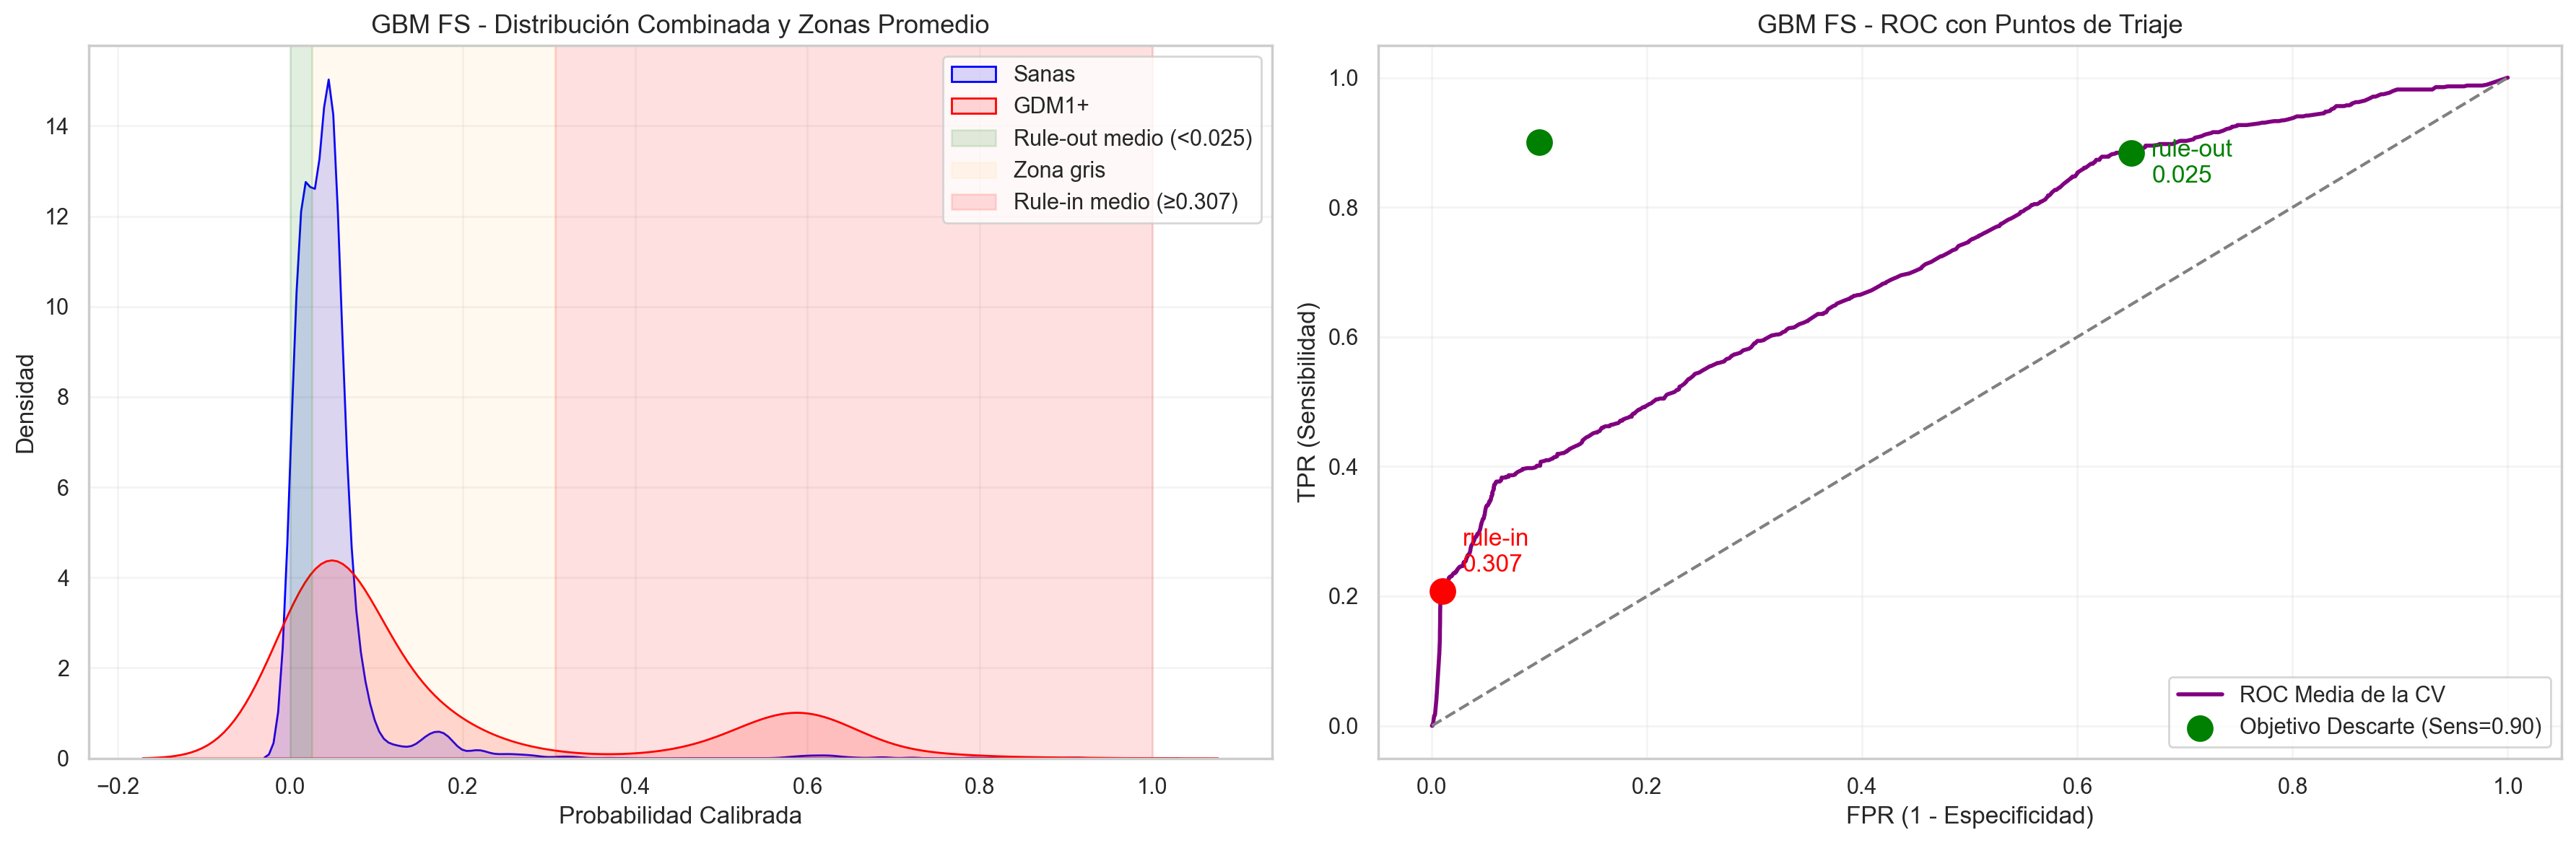


ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - GBM FS
Top-4 usadas: ['1T hemoglobina glicada', 'bmi', '1t glucosa', 'factores riesgo']
Features top-4 sin corte definido: ['factores riesgo']
Modo de thr_in: precision
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
AUC-ROC colectiva: 0.7177
Umbral de Descarte Promedio: 0.0249 ± 0.0132
Umbral de Confirmación Promedio: 0.3074 ± 0.1887
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3640 (24.2%) |   33 pts. |   0.9% | Falla en 33 casos (96.0% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 10756 (71.6%) |  562 pts. |   5.2% | Absorbe al 68.5% de las enfermas
RULE-IN (Confirmación)    |  624 ( 4.2%) |  225 pts. |  36.1% | Precisión Real Consolidada del 36.1%
--

In [88]:
# ======================================================================
# 6. Triaje Clínico por Validación Cruzada con dos modos de umbral - GBM FS
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier

# -----------------------------
# Comprobaciones previas
# -----------------------------
if "top_4_features_gbm" not in globals():
    raise NameError("Primero define `top_4_features_gbm`.")
if "cuts_seleccionados_gbm" not in globals():
    raise NameError("Primero define `cuts_seleccionados_gbm`.")

assert len(top_4_features_gbm) == 4, f"Se esperaban 4 features y hay {len(top_4_features_gbm)}"
assert all(f in X_train.columns for f in top_4_features_gbm), "Alguna feature del top-4 no existe en `X_train`"

# Cortes para el top-4: usamos solo los que existan realmente
cuts_map_gbm_fs = {
    k: cuts_seleccionados_gbm[k]
    for k in top_4_features_gbm
    if k in cuts_seleccionados_gbm
}
missing_cuts = [k for k in top_4_features_gbm if k not in cuts_seleccionados_gbm]

print("Top-4 variables seleccionadas:", top_4_features_gbm)
print("Cortes usados para GBM FS:", cuts_map_gbm_fs)
print("Features del top-4 sin corte definido:", missing_cuts if missing_cuts else "ninguna")

# -----------------------------
# Pipeline + GridSearch dentro de la misma celda
# -----------------------------
pipe_gbm_fs = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top_4_features_gbm], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_gbm_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_gbm_fs = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [0.8, 1.0]
}

grid_gbm_fs = GridSearchCV(
    estimator=pipe_gbm_fs,
    param_grid=param_grid_gbm_fs,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV sobre GBM con feature selection...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_gbm_fs.fit(X_train, y_train)

print(f"\nMejor ROC-AUC (CV): {grid_gbm_fs.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_gbm_fs.best_params_}")

best_estimator_gbm_fs = grid_gbm_fs.best_estimator_

if hasattr(best_estimator_gbm_fs, "named_steps"):
    clf_base_gbm_fs = clone(best_estimator_gbm_fs.named_steps["clf"])
else:
    clf_base_gbm_fs = clone(best_estimator_gbm_fs)

pipe_gbm_top4_cv = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top_4_features_gbm], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_gbm_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", clf_base_gbm_fs)
])

# -----------------------------
# Configuración CV de triaje
# -----------------------------
n_splits = 5
n_repeats = 10
cv_triaje_gbm = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

modo_thr_in = "precision"   # "precision" o "manual"
target_sens = 0.90
target_prec = 0.40
thr_in_manual = 0.25

# -----------------------------
# Acumuladores
# -----------------------------
ahorros_folds_gbm = []
umbrales_out_gbm = []
umbrales_in_gbm = []
probas_normalizadas_grafico_gbm = []
reales_acumulados_grafico_gbm = []

total_pacientes_evaluados_gbm = 0
total_positivos_evaluados_gbm = 0

counts_globales_gbm = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_gbm = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} iteraciones con optimización local de umbrales para GBM FS...")
print("Selector top-4:", pipe_gbm_top4_cv.named_steps["select"])

# -----------------------------
# Loop CV
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv_triaje_gbm.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    assert list(X_tr_fold[top_4_features_gbm].columns) == top_4_features_gbm
    assert list(X_val_fold[top_4_features_gbm].columns) == top_4_features_gbm

    calibrador_fold = CalibratedClassifierCV(
        estimator=pipe_gbm_top4_cv,
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else thrs_roc_f[0]

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out_gbm.append(thr_out_f)
    umbrales_in_gbm.append(thr_in_f)

    probas_normalizadas_grafico_gbm.extend(probas_val.tolist())
    reales_acumulados_grafico_gbm.extend(y_val_arr.tolist())

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados_gbm += len(df_f)
    total_positivos_evaluados_gbm += int(df_f["Real"].sum())

    for c in counts_globales_gbm.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_gbm[c] += len(sub_c)
        positives_globales_gbm[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_gbm.append(((len(df_f) - count_gris) / len(df_f)) * 100)

    print(f"Fold {fold:02d} | top-4 OK | thr_out={thr_out_f:.4f} | thr_in={thr_in_f:.4f}")

# -----------------------------
# Agregados
# -----------------------------
mean_thr_out_gbm = float(np.mean(umbrales_out_gbm))
mean_thr_in_gbm = float(np.mean(umbrales_in_gbm))
std_thr_out_gbm = float(np.std(umbrales_out_gbm))
std_thr_in_gbm = float(np.std(umbrales_in_gbm))

df_grafico_global_gbm = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_gbm,
    "Real": reales_acumulados_grafico_gbm
})

auc_cv_global_gbm = roc_auc_score(df_grafico_global_gbm["Real"], df_grafico_global_gbm["Prob"])

# -----------------------------
# Gráficas
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_gbm[df_grafico_global_gbm["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_gbm[df_grafico_global_gbm["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM1+", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_gbm, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_gbm:.3f})")
ax1.axvspan(mean_thr_out_gbm, mean_thr_in_gbm, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_gbm, 1, color="red", alpha=0.12, label=f"Rule-in medio (≥{mean_thr_in_gbm:.3f})")
ax1.set_title("GBM FS - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_gbm["Real"], df_grafico_global_gbm["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_gbm))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_gbm))

ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.annotate(
    f"rule-out\n{mean_thr_out_gbm:.3f}",
    (fpr_g[idx_out_global], tpr_g[idx_out_global]),
    textcoords="offset points", xytext=(10, -15), ha="left", color="green"
)
ax2.annotate(
    f"rule-in\n{mean_thr_in_gbm:.3f}",
    (fpr_g[idx_in_global], tpr_g[idx_in_global]),
    textcoords="offset points", xytext=(10, 10), ha="left", color="red"
)

ax2.set_title("GBM FS - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -----------------------------
# Reporte numérico completo
# -----------------------------
print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - GBM FS")
print("=" * 90)
print(f"Top-4 usadas: {top_4_features_gbm}")
print(f"Features top-4 sin corte definido: {missing_cuts if missing_cuts else 'ninguna'}")
print(f"Modo de thr_in: {modo_thr_in}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_gbm} | Positivos Reales Totales: {int(total_positivos_evaluados_gbm)}")
print(f"AUC-ROC colectiva: {auc_cv_global_gbm:.4f}")
print(f"Umbral de Descarte Promedio: {mean_thr_out_gbm:.4f} ± {std_thr_out_gbm:.4f}")
print(f"Umbral de Confirmación Promedio: {mean_thr_in_gbm:.4f} ± {std_thr_in_gbm:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_gbm[cat]
    positives = positives_globales_gbm[cat]
    perc_total = (count / total_pacientes_evaluados_gbm) * 100 if total_pacientes_evaluados_gbm > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_gbm) * 100 if total_positivos_evaluados_gbm > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_gbm):.1%} de las enfermas" if total_positivos_evaluados_gbm > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds_gbm):.1f}% ± {np.std(ahorros_folds_gbm):.1f}% de la población analizada.")
print("=" * 90)

## Pruebas con XGBOOST

Top-4 variables seleccionadas: ['1t glucosa', 'factores riesgo', 'bmi', '1T hemoglobina glicada']
Cortes usados para XGB FS: {'1t glucosa': 81.0, 'bmi': 26.53, '1T hemoglobina glicada': 5.1}
Features del top-4 sin corte definido: ['factores riesgo']
Ejecutando GridSearchCV sobre XGB con feature selection...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Mejor ROC-AUC (CV): 0.7464
Mejores hiperparámetros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0}
Ejecutando 50 iteraciones con optimización local de umbrales para XGB FS...
Selector top-4: FunctionTransformer(func=<function <lambda> at 0x000001A98DC3C4A0>)
Fold 01 | top-4 OK | thr_out=0.0219 | thr_in=0.1277
Fold 02 | top-4 OK | thr_out=0.0315 | thr_in=0.1308
Fold 03 | top-4 OK | thr_out=0.0150 | thr_in=0.4349
Fold 04 | top-4 OK | thr_out=0.0331 | thr_in=0.1340
Fold 05 | top-4 OK | thr_out=0.0261 | thr_in=0.4630
Fold 06 | top-4 OK | thr_ou

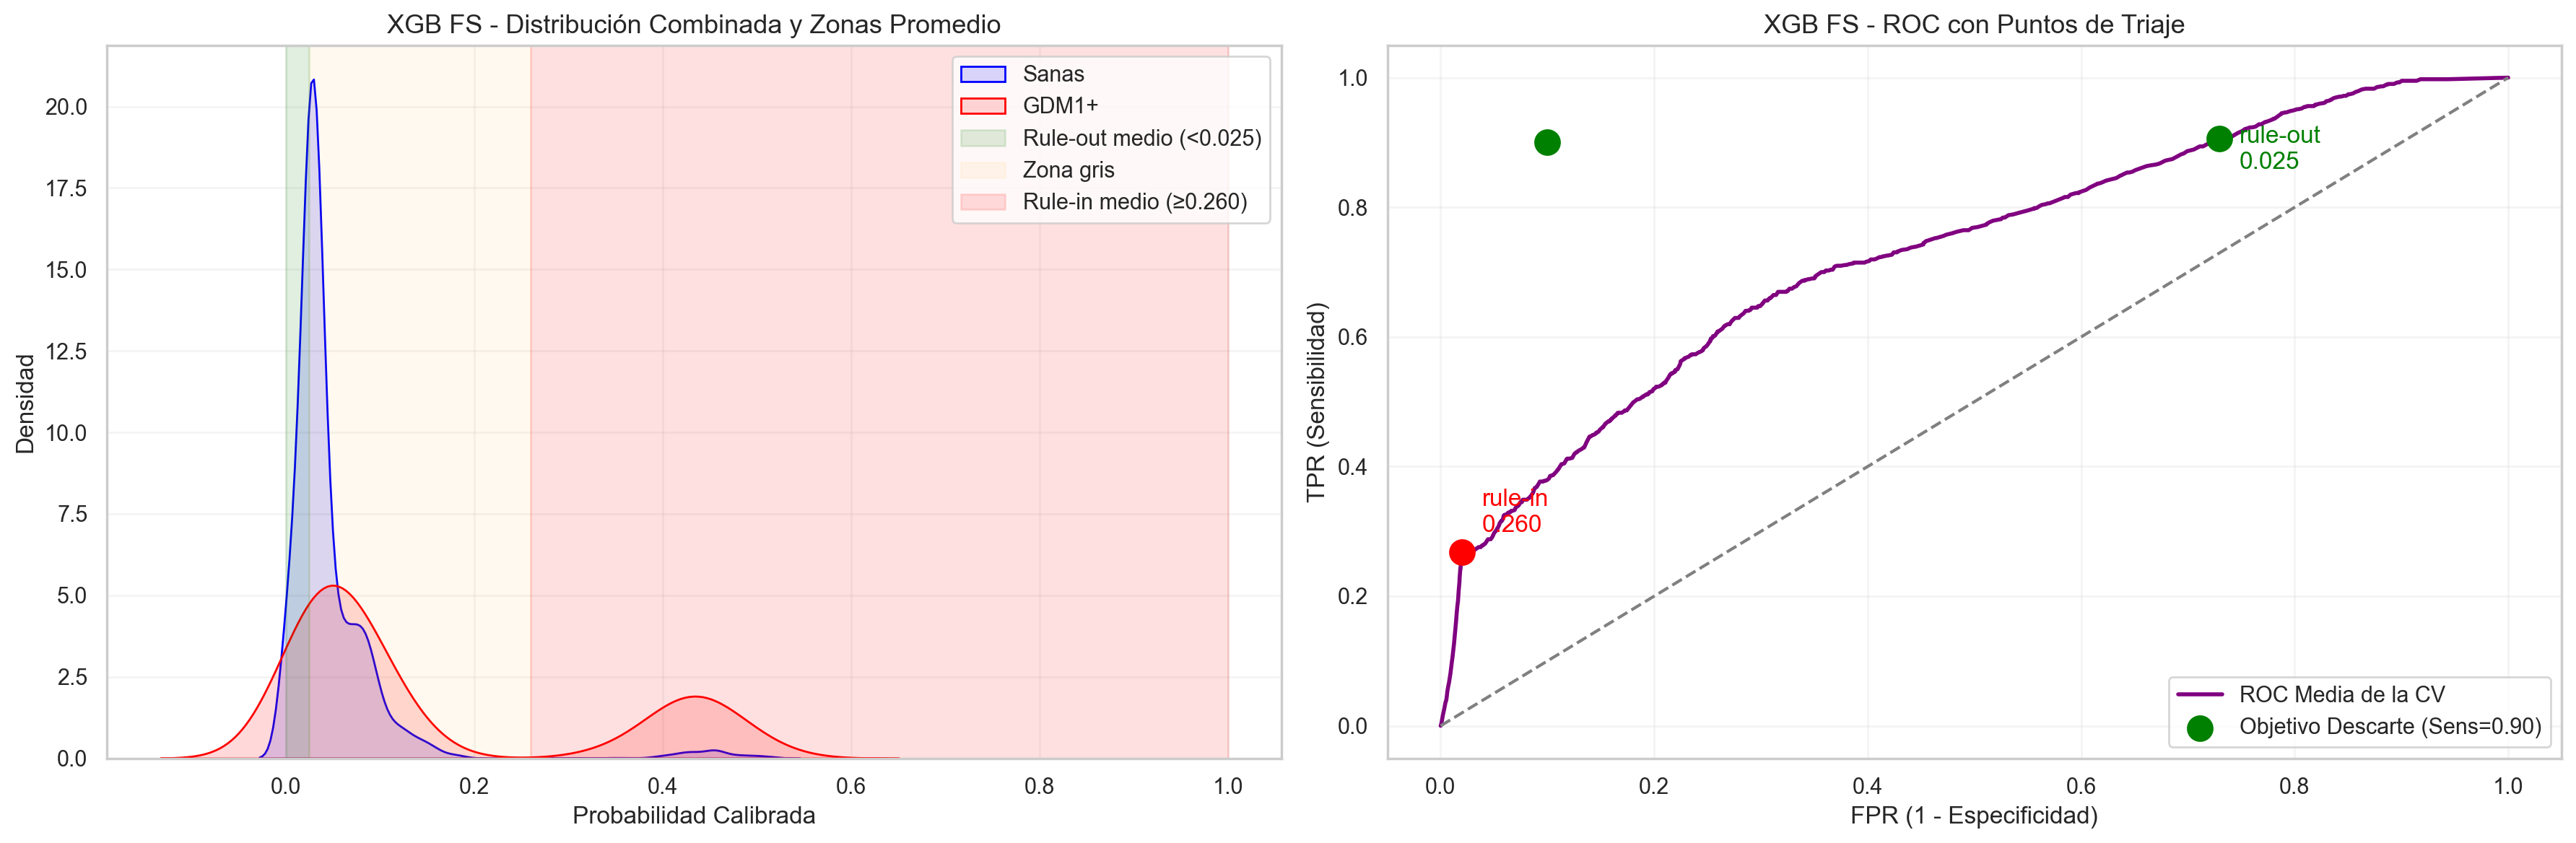


ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - XGB FS
Top-4 usadas: ['1t glucosa', 'factores riesgo', 'bmi', '1T hemoglobina glicada']
Features top-4 sin corte definido: ['factores riesgo']
Modo de thr_in: precision
Población evaluada acumulada: 15020 | Positivos Reales Totales: 820
AUC-ROC colectiva: 0.7295
Umbral de Descarte Promedio: 0.0245 ± 0.0073
Umbral de Confirmación Promedio: 0.2597 ± 0.1516
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 3185 (21.2%) |   27 pts. |   0.8% | Falla en 27 casos (96.7% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 10867 (72.4%) |  525 pts. |   4.8% | Absorbe al 64.0% de las enfermas
RULE-IN (Confirmación)    |  968 ( 6.4%) |  268 pts. |  27.7% | Precisión Real Consolidada del 27.7%
--

In [99]:
# ======================================================================
# 6. Triaje Clínico por Validación Cruzada con dos modos de umbral - XGB FS
# ======================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone
from xgboost import XGBClassifier

# -----------------------------
# Comprobaciones previas
# -----------------------------
if "top_4_features_xgb" not in globals():
    raise NameError("Primero define `top_4_features_xgb`.")
if "cuts_seleccionados_xgb" not in globals():
    raise NameError("Primero define `cuts_seleccionados_xgb`.")

assert len(top_4_features_xgb) == 4, f"Se esperaban 4 features y hay {len(top_4_features_xgb)}"
assert all(f in X_train.columns for f in top_4_features_xgb), "Alguna feature del top-4 no existe en `X_train`"

# Cortes para el top-4: usamos solo los que existan realmente
cuts_map_xgb_fs = {
    k: cuts_seleccionados_xgb[k]
    for k in top_4_features_xgb
    if k in cuts_seleccionados_xgb
}
missing_cuts = [k for k in top_4_features_xgb if k not in cuts_seleccionados_xgb]

print("Top-4 variables seleccionadas:", top_4_features_xgb)
print("Cortes usados para XGB FS:", cuts_map_xgb_fs)
print("Features del top-4 sin corte definido:", missing_cuts if missing_cuts else "ninguna")

# -----------------------------
# Pipeline + GridSearch dentro de la misma celda
# -----------------------------
pipe_xgb_fs = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top_4_features_xgb], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_xgb_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        tree_method="hist"
    ))
])

param_grid_xgb_fs = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

grid_xgb_fs = GridSearchCV(
    estimator=pipe_xgb_fs,
    param_grid=param_grid_xgb_fs,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV sobre XGB con feature selection...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_xgb_fs.fit(X_train, y_train)

print(f"\nMejor ROC-AUC (CV): {grid_xgb_fs.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_xgb_fs.best_params_}")

best_estimator_xgb_fs = grid_xgb_fs.best_estimator_

if hasattr(best_estimator_xgb_fs, "named_steps"):
    clf_base_xgb_fs = clone(best_estimator_xgb_fs.named_steps["clf"])
else:
    clf_base_xgb_fs = clone(best_estimator_xgb_fs)

pipe_xgb_top4_cv = Pipeline([
    ("select", FunctionTransformer(lambda X: X[top_4_features_xgb], validate=False)),
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_map_xgb_fs)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False)),
    ("clf", clf_base_xgb_fs)
])

# -----------------------------
# Configuración CV de triaje
# -----------------------------
n_splits = 5
n_repeats = 10
cv_triaje_xgb = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

modo_thr_in = "precision"   # "precision" o "manual"
target_sens = 0.90
target_prec = 0.40
thr_in_manual = 0.25

# -----------------------------
# Acumuladores
# -----------------------------
ahorros_folds_xgb = []
umbrales_out_xgb = []
umbrales_in_xgb = []
probas_normalizadas_grafico_xgb = []
reales_acumulados_grafico_xgb = []

total_pacientes_evaluados_xgb = 0
total_positivos_evaluados_xgb = 0

counts_globales_xgb = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales_xgb = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {n_splits * n_repeats} iteraciones con optimización local de umbrales para XGB FS...")
print("Selector top-4:", pipe_xgb_top4_cv.named_steps["select"])

# -----------------------------
# Loop CV
# -----------------------------
for fold, (train_idx, val_idx) in enumerate(cv_triaje_xgb.split(X_train, y_train), start=1):
    X_tr_fold = X_train.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    assert list(X_tr_fold[top_4_features_xgb].columns) == top_4_features_xgb
    assert list(X_val_fold[top_4_features_xgb].columns) == top_4_features_xgb

    calibrador_fold = CalibratedClassifierCV(
        estimator=pipe_xgb_top4_cv,
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrador_fold.fit(X_tr_fold, y_tr_fold)

    probas_val = calibrador_fold.predict_proba(X_val_fold)[:, 1]
    y_val_arr = y_val_fold.to_numpy()

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_arr, probas_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else thrs_roc_f[0]

    if modo_thr_in == "precision":
        precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_arr, probas_val)
        idx_in_list = np.where(precision_f >= target_prec)[0]
        if len(idx_in_list) > 0 and idx_in_list[0] < len(thresholds_pr_f):
            thr_in_f = thresholds_pr_f[idx_in_list[0]]
        else:
            thr_in_f = np.percentile(probas_val, 90)
    elif modo_thr_in == "manual":
        thr_in_f = thr_in_manual
    else:
        raise ValueError("modo_thr_in debe ser 'precision' o 'manual'")

    if thr_in_f <= thr_out_f:
        thr_in_f = thr_out_f + 0.05

    umbrales_out_xgb.append(thr_out_f)
    umbrales_in_xgb.append(thr_in_f)

    probas_normalizadas_grafico_xgb.extend(probas_val.tolist())
    reales_acumulados_grafico_xgb.extend(y_val_arr.tolist())

    cats_f = []
    for p in probas_val:
        if p < thr_out_f:
            cats_f.append("RULE-OUT (Descarte)")
        elif p >= thr_in_f:
            cats_f.append("RULE-IN (Confirmación)")
        else:
            cats_f.append("ZONA GRIS (Sobrecarga)")

    df_f = pd.DataFrame({"Real": y_val_arr, "Cat": cats_f})

    total_pacientes_evaluados_xgb += len(df_f)
    total_positivos_evaluados_xgb += int(df_f["Real"].sum())

    for c in counts_globales_xgb.keys():
        sub_c = df_f[df_f["Cat"] == c]
        counts_globales_xgb[c] += len(sub_c)
        positives_globales_xgb[c] += int(sub_c["Real"].sum())

    count_gris = len(df_f[df_f["Cat"] == "ZONA GRIS (Sobrecarga)"])
    ahorros_folds_xgb.append(((len(df_f) - count_gris) / len(df_f)) * 100)

    print(f"Fold {fold:02d} | top-4 OK | thr_out={thr_out_f:.4f} | thr_in={thr_in_f:.4f}")

# -----------------------------
# Agregados
# -----------------------------
mean_thr_out_xgb = float(np.mean(umbrales_out_xgb))
mean_thr_in_xgb = float(np.mean(umbrales_in_xgb))
std_thr_out_xgb = float(np.std(umbrales_out_xgb))
std_thr_in_xgb = float(np.std(umbrales_in_xgb))

df_grafico_global_xgb = pd.DataFrame({
    "Prob": probas_normalizadas_grafico_xgb,
    "Real": reales_acumulados_grafico_xgb
})

auc_cv_global_xgb = roc_auc_score(df_grafico_global_xgb["Real"], df_grafico_global_xgb["Prob"])

# -----------------------------
# Gráficas
# -----------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global_xgb[df_grafico_global_xgb["Real"] == 0],
    x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.15, cut=3
)
sns.kdeplot(
    data=df_grafico_global_xgb[df_grafico_global_xgb["Real"] == 1],
    x="Prob", fill=True, ax=ax1, label="GDM1+", color="red", alpha=0.15, cut=3
)

ax1.axvspan(0, mean_thr_out_xgb, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out_xgb:.3f})")
ax1.axvspan(mean_thr_out_xgb, mean_thr_in_xgb, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in_xgb, 1, color="red", alpha=0.12, label=f"Rule-in medio (≥{mean_thr_in_xgb:.3f})")
ax1.set_title("XGB FS - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad Calibrada")
ax1.set_ylabel("Densidad")
ax1.legend(loc="upper right")
ax1.grid(alpha=0.2)

fpr_g, tpr_g, thresholds_g = roc_curve(df_grafico_global_xgb["Real"], df_grafico_global_xgb["Prob"])
ax2.plot(fpr_g, tpr_g, color="purple", lw=2, label="ROC Media de la CV")
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.scatter(1 - target_sens, target_sens, color="green", s=150, zorder=5, label=f"Objetivo Descarte (Sens={target_sens:.2f})")

idx_out_global = np.argmin(np.abs(thresholds_g - mean_thr_out_xgb))
idx_in_global = np.argmin(np.abs(thresholds_g - mean_thr_in_xgb))

ax2.scatter(fpr_g[idx_out_global], tpr_g[idx_out_global], color="green", s=150, zorder=6)
ax2.scatter(fpr_g[idx_in_global], tpr_g[idx_in_global], color="red", s=150, zorder=6)

ax2.annotate(
    f"rule-out\n{mean_thr_out_xgb:.3f}",
    (fpr_g[idx_out_global], tpr_g[idx_out_global]),
    textcoords="offset points", xytext=(10, -15), ha="left", color="green"
)
ax2.annotate(
    f"rule-in\n{mean_thr_in_xgb:.3f}",
    (fpr_g[idx_in_global], tpr_g[idx_in_global]),
    textcoords="offset points", xytext=(10, 10), ha="left", color="red"
)

ax2.set_title("XGB FS - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR (1 - Especificidad)")
ax2.set_ylabel("TPR (Sensibilidad)")
ax2.legend(loc="lower right")
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# -----------------------------
# Reporte numérico completo
# -----------------------------
print("\n" + "=" * 90)
print("ANÁLISIS DE IMPACTO CLÍNICO REPRODUCIBLE (UMBRALES LOCALES) - XGB FS")
print("=" * 90)
print(f"Top-4 usadas: {top_4_features_xgb}")
print(f"Features top-4 sin corte definido: {missing_cuts if missing_cuts else 'ninguna'}")
print(f"Modo de thr_in: {modo_thr_in}")
print(f"Población evaluada acumulada: {total_pacientes_evaluados_xgb} | Positivos Reales Totales: {int(total_positivos_evaluados_xgb)}")
print(f"AUC-ROC colectiva: {auc_cv_global_xgb:.4f}")
print(f"Umbral de Descarte Promedio: {mean_thr_out_xgb:.4f} ± {std_thr_out_xgb:.4f}")
print(f"Umbral de Confirmación Promedio: {mean_thr_in_xgb:.4f} ± {std_thr_in_xgb:.4f}")
print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    count = counts_globales_xgb[cat]
    positives = positives_globales_xgb[cat]
    perc_total = (count / total_pacientes_evaluados_xgb) * 100 if total_pacientes_evaluados_xgb > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_promedio = (1 - positives / total_positivos_evaluados_xgb) * 100 if total_positivos_evaluados_xgb > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_promedio:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados_xgb):.1%} de las enfermas" if total_positivos_evaluados_xgb > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds_xgb):.1f}% ± {np.std(ahorros_folds_xgb):.1f}% de la población analizada.")
print("=" * 90)